### Convex optimizations with noise

In this notebook, we will test how the models behave on functions with noise.

In [1]:
import gymnasium as gym
import src.gymnasium_envs.convex_optimization_env

import src.utils.exps_utils as exps

seed = 42
in_features = 2
max_iterations = 10000
add_noise = True

Let's test a noise-free 2D model on a noise-added problem.

In [2]:
env_id = "convex_optimization_env/ConvexOptimization-v1"
stats = "../models/2d_convex_optimization_vec_normalize_stats.pkl"
model = "../models/2d_convex_optimization"

env_config = exps.get_env_config(seed, in_features, max_iterations, add_noise)
model_dir = exps.get_model_dir(stats, model)

In [3]:
result = exps.optimize_exp(env_config, model_dir)

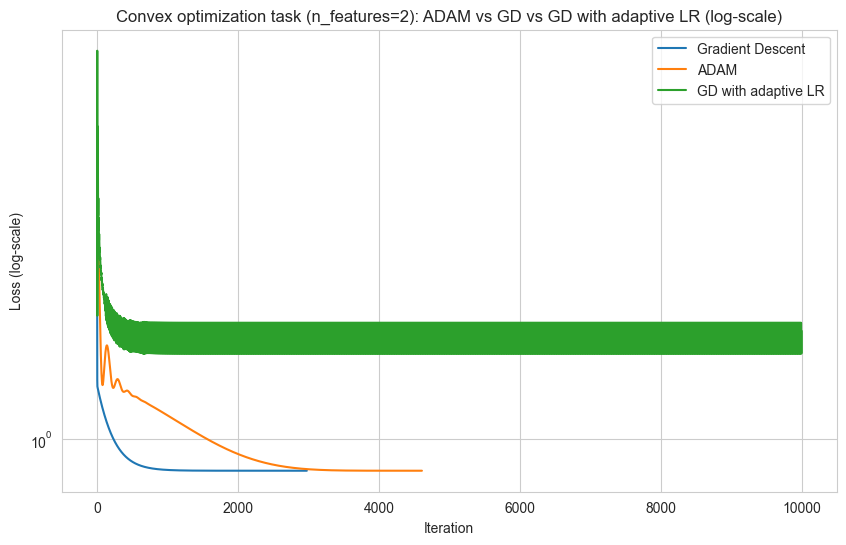

In [4]:
exps.plot_converging_comparasion(result, dim=in_features)

As we can see, such a model gets stuck in local extremum.

Let's add episodes with the addition of noisy functions to the training data. This way we get a model that learns to escape local minimum.

In [5]:
env_id = "non_convex_optimization_env/NonConvexOptimization-v0"
stats = "../models/2d_noise_convex_optimization_vec_normalize_stats.pkl"
model = "../models/2d_noise_convex_optimization"

env_config = exps.get_env_config(seed, in_features, max_iterations, add_noise)
model_dir = exps.get_model_dir(stats, model)

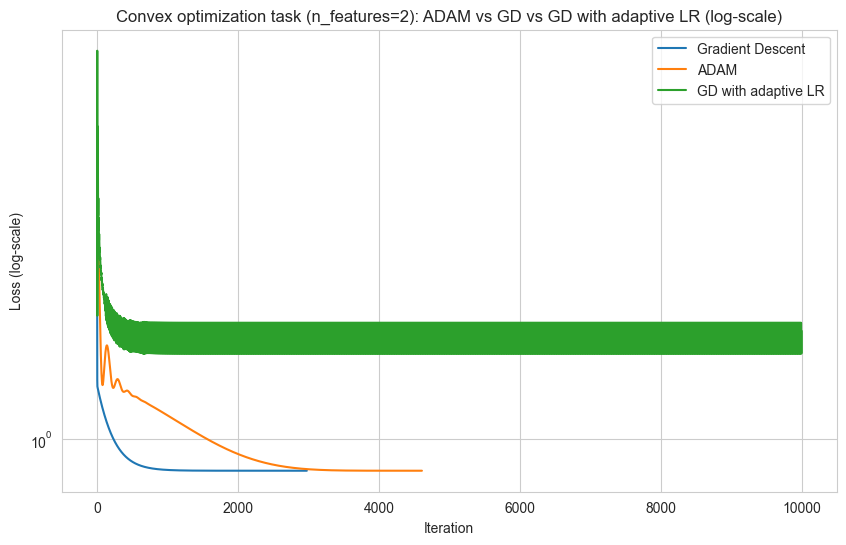

In [6]:
result = exps.optimize_exp(env_config, model_dir)
exps.plot_converging_comparasion(result, dim=in_features)